In [1]:
import os
import gc
import pickle
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [2]:
# ── UPDATE THIS PATH ─────────────────────────────────────────────────────────
dataset_path = r"D:\VS Code\Python\plant disease idetification\plantvillage dataset\color"
# ─────────────────────────────────────────────────────────────────────────────

IMAGE_SIZE  = 32
BATCH_SIZE  = 32
SAMPLE_SIZE = 5000

# ── Generators ───────────────────────────────────────────────────────────────
datagen_train = ImageDataGenerator(rescale=1./255, validation_split=0.2,
    rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
    horizontal_flip=True, zoom_range=0.1, fill_mode='nearest')
datagen_val = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen_train.flow_from_directory(dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True, seed=42)
val_gen = datagen_val.flow_from_directory(dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False, seed=42)

num_classes = train_gen.num_classes
class_names = list(train_gen.class_indices.keys())

encoder = LabelEncoder()
encoder.fit(class_names)

# ── 5 000-sample draw for SVM / RF ───────────────────────────────────────────
datagen_flat = ImageDataGenerator(rescale=1./255)
flat_gen = datagen_flat.flow_from_directory(dataset_path,
    target_size=(IMAGE_SIZE, IMAGE_SIZE), batch_size=BATCH_SIZE,
    class_mode='sparse', shuffle=True, seed=42)

sample_x, sample_y = [], []
for imgs, lbls in flat_gen:
    sample_x.append(imgs); sample_y.append(lbls)
    if sum(len(b) for b in sample_x) >= SAMPLE_SIZE:
        break
sample_x = np.concatenate(sample_x)[:SAMPLE_SIZE]
sample_y = np.concatenate(sample_y)[:SAMPLE_SIZE].astype(int)

X_flat = sample_x.reshape(len(sample_x), -1).astype(np.float32)
del sample_x; gc.collect()

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_flat, sample_y, test_size=0.2, random_state=42, stratify=sample_y)
del X_flat; gc.collect()

pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca  = pca.transform(X_test_s)
del X_train_s, X_test_s; gc.collect()

print("✅ Setup complete — generators, encoder, PCA ready.")
print(f"   Classes: {num_classes}  |  Train: {train_gen.n}  |  Val: {val_gen.n}")
print(f"   PCA sample: {SAMPLE_SIZE} images  |  Train PCA: {X_train_pca.shape}  |  Test PCA: {X_test_pca.shape}")

Found 49961 images belonging to 38 classes.
Found 12476 images belonging to 38 classes.
Found 62437 images belonging to 38 classes.
✅ Setup complete — generators, encoder, PCA ready.
   Classes: 38  |  Train: 49961  |  Val: 12476
   PCA sample: 5000 images  |  Train PCA: (4000, 100)  |  Test PCA: (1000, 100)


In [3]:
print("Training SVM on 5,000-sample PCA features ...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_pca, y_train_s)
print("✅ SVM training complete.")

Training SVM on 5,000-sample PCA features ...
✅ SVM training complete.


In [4]:
print("Training Random Forest ...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_pca, y_train_s)
print("✅ Random Forest training complete.")

Training Random Forest ...
✅ Random Forest training complete.


In [5]:
gc.collect()
tf.keras.backend.clear_session()

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Head
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
model.summary()

C:\Users\Vaseem\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           9,766 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 627,942 (2.40 MB)

 Trainable params: 627,750 (2.39 MB)

 Non-trainable params: 192 (768.00 B)

In [6]:
# Generator-based fit — only one batch (32 images) in RAM at a time
history = model.fit(
    train_gen,
    epochs          = 10,
    validation_data = val_gen,
    verbose         = 1
)
print("\n✅ CNN training complete.")

Epoch 1/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 163s 103ms/step - accuracy: 0.6125 - loss: 1.3422 - val_accuracy: 0.5838 - val_loss: 1.7393
Epoch 2/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.7722 - loss: 0.7286 - val_accuracy: 0.4982 - val_loss: 3.4345
Epoch 3/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.8208 - loss: 0.5679 - val_accuracy: 0.8067 - val_loss: 0.6494
Epoch 4/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 128s 82ms/step - accuracy: 0.8447 - loss: 0.4899 - val_accuracy: 0.6534 - val_loss: 1.6279
Epoch 5/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 150s 96ms/step - accuracy: 0.8650 - loss: 0.4265 - val_accuracy: 0.8587 - val_loss: 0.4515
Epoch 6/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 138s 89ms/step - accuracy: 0.8809 - loss: 0.3784 - val_accuracy: 0.7841 - val_loss: 0.8370
Epoch 7/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 127s 81ms/step - accuracy: 0.8895 - loss: 0.3525 - val_accuracy: 0.7025 - val_loss: 1.3353
Epoch 8/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 145s 93ms/step - accuracy:

In [7]:
# ── SVM ───────────────────────────────────────────────────────────────────────
svm_pred     = svm_model.predict(X_test_pca)
svm_accuracy = accuracy_score(y_test_s, svm_pred)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf_pred      = rf_model.predict(X_test_pca)
rf_accuracy  = accuracy_score(y_test_s, rf_pred)

# ── CNN — batch-wise to avoid OOM ────────────────────────────────────────────
cnn_loss, cnn_accuracy = model.evaluate(val_gen, verbose=0)

y_pred_cnn, y_true_cnn = [], []
val_gen.reset()
for imgs, lbls in val_gen:
    preds = model.predict(imgs, verbose=0)
    y_pred_cnn.extend(np.argmax(preds, axis=1))
    y_true_cnn.extend(np.argmax(lbls,  axis=1))
    if len(y_true_cnn) >= val_gen.n:
        break
y_pred_cnn = np.array(y_pred_cnn[:val_gen.n])
y_true_cnn = np.array(y_true_cnn[:val_gen.n])

print(f"SVM Accuracy           : {svm_accuracy*100:.2f}%  (on 5,000-sample subset)")
print(f"Random Forest Accuracy : {rf_accuracy*100:.2f}%  (on 5,000-sample subset)")
print(f"CNN Accuracy           : {cnn_accuracy*100:.2f}%  (on full validation set)")
print("\n✅ Model Evaluation complete.")

SVM Accuracy           : 64.50%  (on 5,000-sample subset)
Random Forest Accuracy : 51.80%  (on 5,000-sample subset)
CNN Accuracy           : 83.91%  (on full validation set)

✅ Model Evaluation complete.


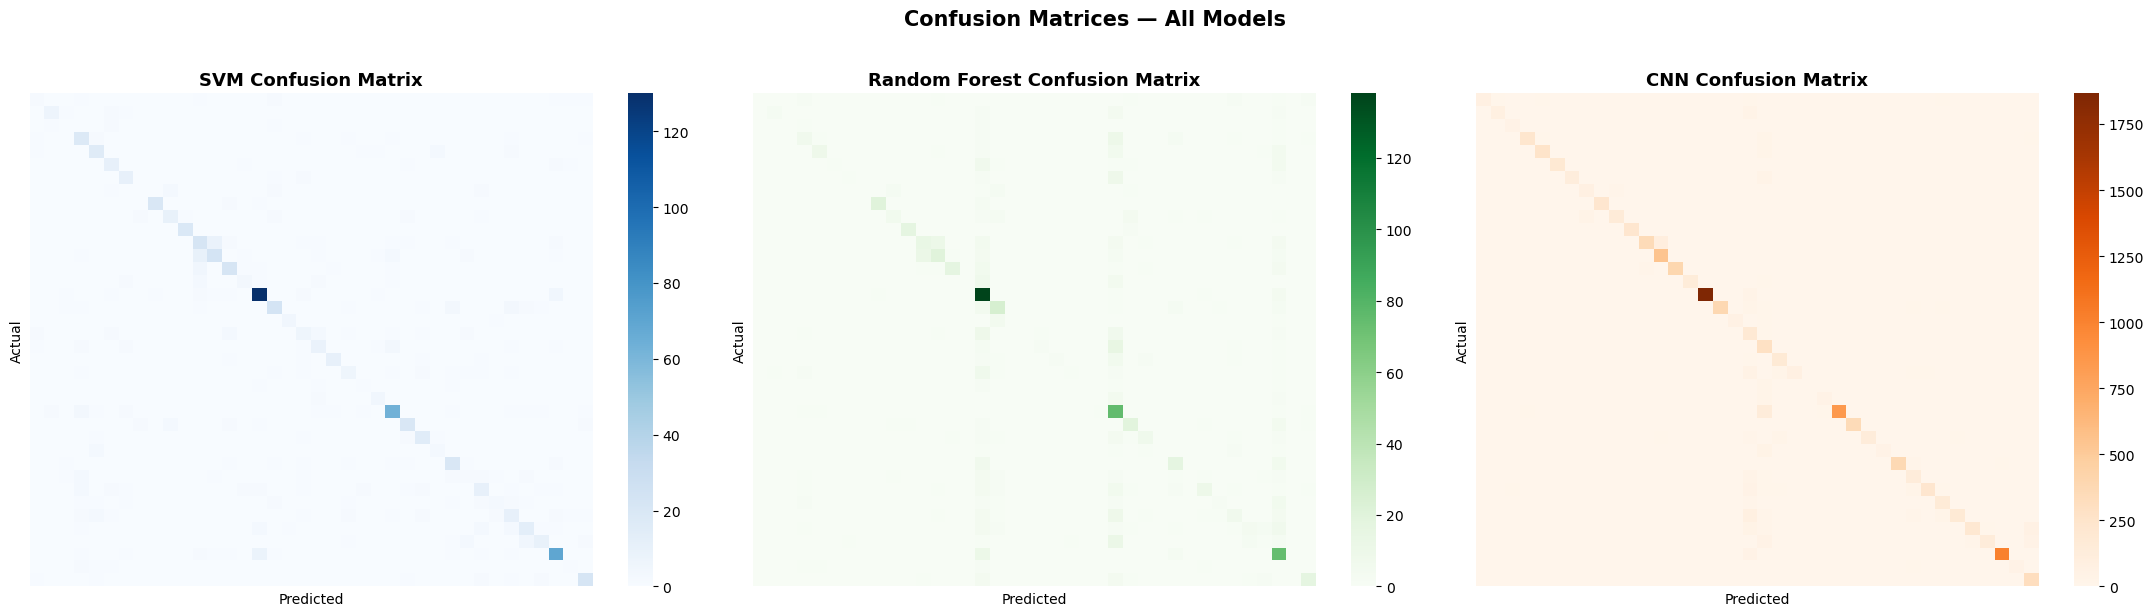

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

cm_data_list = [
    (confusion_matrix(y_test_s, svm_pred),     "SVM Confusion Matrix",           "Blues"),
    (confusion_matrix(y_test_s, rf_pred),      "Random Forest Confusion Matrix", "Greens"),
    (confusion_matrix(y_true_cnn, y_pred_cnn), "CNN Confusion Matrix",           "Oranges"),
]

for ax, (cm_data, title, cmap) in zip(axes, cm_data_list):
    sns.heatmap(cm_data, annot=False, fmt='d', cmap=cmap, ax=ax,
                xticklabels=False, yticklabels=False)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Models", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Classification Report — CNN

In [9]:
target_names = [c.replace('___', ' — ').replace('_', ' ') for c in class_names]
print(classification_report(y_true_cnn, y_pred_cnn, target_names=target_names))

                                                    precision    recall  f1-score   support

                                Apple — Apple scab       0.91      0.58      0.71       126
                                 Apple — Black rot       0.77      0.70      0.73       124
                          Apple — Cedar apple rust       0.76      0.87      0.81        55
                                   Apple — healthy       0.94      0.72      0.81       329
                               Blueberry — healthy       0.91      0.86      0.89       300
          Cherry (including sour) — Powdery mildew       0.96      0.90      0.93       210
                 Cherry (including sour) — healthy       0.96      0.76      0.85       170
Corn (maize) — Cercospora leaf spot Gray leaf spot       0.64      0.75      0.69       102
                       Corn (maize) — Common rust        1.00      0.97      0.98       238
               Corn (maize) — Northern Leaf Blight       0.91      0.81      0.

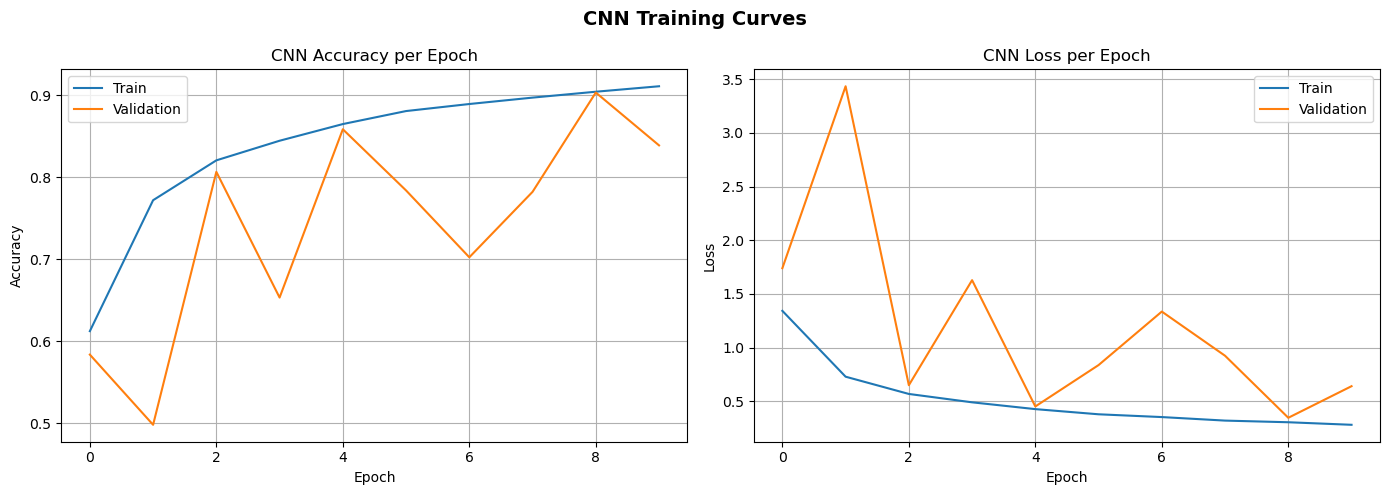

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('CNN Accuracy per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('CNN Loss per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.suptitle("CNN Training Curves", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

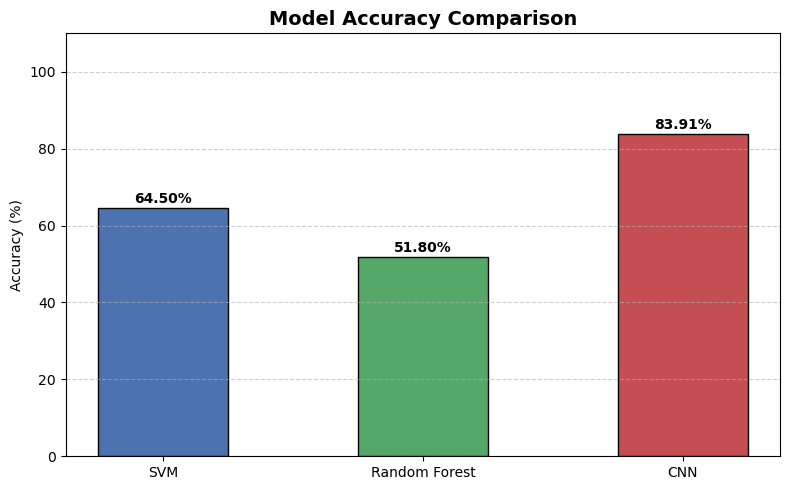


📊 Final Summary:
  SVM                 : 64.50%
  Random Forest       : 51.80%
  CNN                 : 83.91%

🏆 Best Model : CNN


In [11]:
model_names = ['SVM', 'Random Forest', 'CNN']
accuracies  = [svm_accuracy*100, rf_accuracy*100, cnn_accuracy*100]
colors      = ['#4C72B0', '#55A868', '#C44E52']

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 110)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📊 Final Summary:")
for name, acc in zip(model_names, accuracies):
    print(f"  {name:<20}: {acc:.2f}%")
best = model_names[accuracies.index(max(accuracies))]
print(f"\n🏆 Best Model : {best}")

In [12]:
# Save CNN
model.save('plant_disease_cnn.h5')

# Save SVM, RF, PCA, Encoder
with open('svm_model.pkl',   'wb') as f: pickle.dump(svm_model, f)
with open('rf_model.pkl',    'wb') as f: pickle.dump(rf_model,  f)
with open('pca_encoder.pkl', 'wb') as f:
    pickle.dump({'pca': pca, 'encoder': encoder}, f)

print("✅ Models saved:")
print("   plant_disease_cnn.h5")
print("   svm_model.pkl  |  rf_model.pkl  |  pca_encoder.pkl")

✅ Models saved:
   plant_disease_cnn.h5
   svm_model.pkl  |  rf_model.pkl  |  pca_encoder.pkl


In [13]:
def predict_plant_disease(image_path: str, model_type: str = 'cnn') -> dict:
    """
    Predict plant disease from a leaf image.

    Parameters
    ----------
    image_path : str        path to a .jpg / .png leaf image
    model_type : str        'cnn' | 'svm' | 'rf'

    Returns
    -------
    dict  {'predicted_class': str, 'confidence': str}   (confidence only for CNN)
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Cannot read image: {image_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE)).astype(np.float32) / 255.0

    if model_type == 'cnn':
        probs      = model.predict(img[np.newaxis, ...], verbose=0)[0]
        pred_idx   = int(np.argmax(probs))
        confidence = float(probs[pred_idx])
        label      = encoder.classes_[pred_idx]
        return {"predicted_class": label, "confidence": f"{confidence*100:.2f}%"}

    elif model_type in ('svm', 'rf'):
        flat     = img.flatten().reshape(1, -1)
        flat_pca = pca.transform(flat)
        clf      = svm_model if model_type == 'svm' else rf_model
        pred     = clf.predict(flat_pca)[0]
        return {"predicted_class": encoder.classes_[pred]}

    raise ValueError("model_type must be 'cnn', 'svm', or 'rf'")

print("✅ predict_plant_disease() ready.")
print("   Example: predict_plant_disease('leaf.jpg', model_type='cnn')")

✅ predict_plant_disease() ready.
   Example: predict_plant_disease('leaf.jpg', model_type='cnn')
